# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isnull().sum())
print(users.isnull().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isnull().sum())
print(usage.isnull().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  Para users es city y churn_date. Y para usage es date, durantion y lenght.
- Indica qué harías: ¿imputar, eliminar, ignorar? Con city, se investegaría para saber si imputar o déjar como nulo, ya que si es una categoría important. Con churn_date, lo ignoramos, porque muy probablemente quiera decir que ese 88.3% que arroja nulo, es que aún siguen actuvos con su plan, por eso no tienen info. Hablando de los de usage, date es menos del 1% entonces lo ignoramos y durantion y lenght, se investiga, pero muy probablemente lo dejemos como nulos, ya que lenght, no tendrá información si es llamada lo que se analiuza y duration, no tendrá información, si es texto lo que se analiza.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves. Es irrelevante. El mínimo es el primer user_id que hay y el máximo es el último.
- La columna `age`, aquí si hay algo a destacar, y es el mínimo, que es -999 es un valor sentinela, porque seguramente no se tenía la edad de ese usario, pero hay que hacer algo.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves. id y user_id son irrelevantes, porque son los números de usuario y de id que les arroja el sistema.
- Las columnas en durantion y lenght, vemos valores reales en el mínimo, con 0 y en el máximo vemos valores altos, pero posibles. 

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[['city','plan']].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` al parecer tiene casi 500 nulos poco menos y son más opciones siendo Bogotá la más común. 
- La columna `plan` solo tiene dos opciones y es la básica la más común.

In [16]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` solo tiene dos opciones siendo texto la más común y todo indica que no hay nulos. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? En "City" se contraron 469 valores nulos. 
- ¿Qué acción tomarías?  Es considerable ya que es casi un 12.5% de la muestra total de 4 mil datos. Pero como para lo que nos contrataron va más enfocado al funcionamiento y retención del plan como tal, los eliminaría, ya que no hay una forma de saber que pudieramos imputar al ser ciudades, no hay forma de sacar promedio o media. En caso de tener la lada del número pudieramos basarnos en eso para asumir la ciudad.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = 'coerce')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = 'coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

In [20]:
cantidad = (users['reg_date'] > '2024-12-31').sum()
print(f"Usuarios registrados después del 31 de diciembre de 2024: {cantidad}")

Usuarios registrados después del 31 de diciembre de 2024: 40


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves. Hay 39 fechas duplicadas pero ninguna nula. Pero si hay fecha imposibles hay tener del año 2026 si son datos de haste el 2024.

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].describe() 

count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object

In [22]:
cantidad = (usage['date'] > '2024-12-31').sum()
print(f"Actividades después del 31 de diciembre de 2024: {cantidad}")

Actividades después del 31 de diciembre de 2024: 0


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas. No hay ninguna fecha duplicada pero si 50 nulas

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Sí, en el DF de Users.
- ¿Qué harías con ellas? Los eliminaría, ya que solo son 40 y dado que estamos evaluando el comportamiento de los usuarios, el factor tiempo es importante, por ende nos pudiera afectar en nuestro análisis si decidimos imputar.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
age_mediana
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [25]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].isnull().sum())
(users['reg_date'] > '2024-12-31').sum()

40


0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['type'] == 'call']['duration'].isnull().sum()

0

In [27]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['type'] == 'text']['length'].isnull().sum()

0

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`.
En ambos casos tanto en duration como en length los valores con NA son MAR, esto dado que una llamada no puede tener una longitud, tiene una duración, y un texto no puede tener una duración, tiene una longitud. Por eso vemos, en los NA que hay en cada una de estas columnas se deben al tipo. En la columna length siempre que sea llamada habrá un NA y en la columna duration siempre que sea un texto habrá un NA.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns= {'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

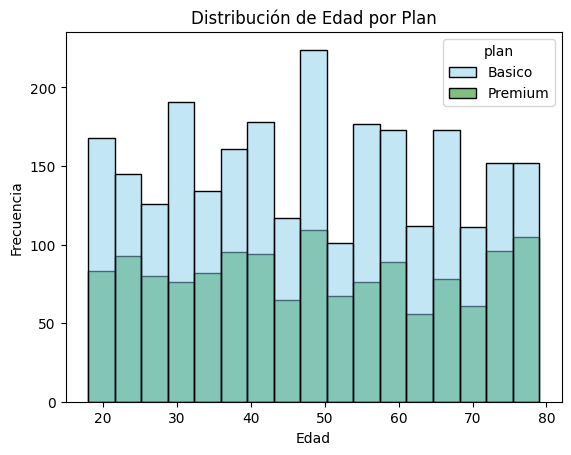

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución. Realmente no hay una diostribución sesgada a la izquierda o a la derecha, es muy aleatoria tanto en cantidad de planes básicos, cómo premium. Lo que si podemos ver es que los usuarios con mayor cantidad de planes premium son los de alrededor de 50 años y los de 75 a 80 años. Esto nos pudiera indicar dos cosas. Los usuarios mayores, prefieren no batallara y que se les incluya todo en su plan y los de 50 años, dado que probablemente sea la etapa en donde mejor les esté yendo econ ómicamente, es donde muchos apuestan por tener un plan más completo. Y con respecto al plan básico, podemos ver que en muchos casos sin importar la edad, es casi el doble de planes contratados que el premium.

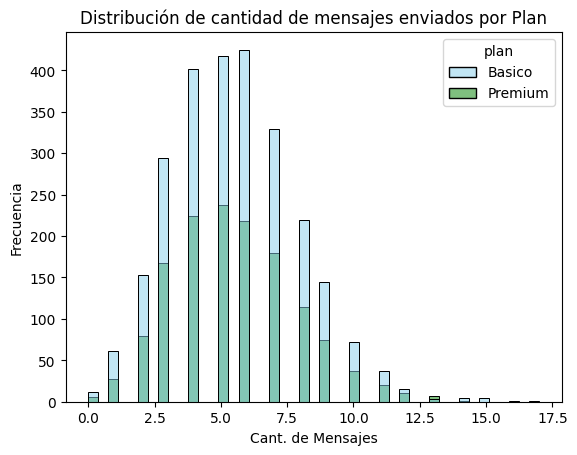

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de cantidad de mensajes enviados por Plan')
plt.xlabel('Cant. de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Aquí si podemos ver picos más claros. Y es que en promedio, la mayoría de usuarios envía entre 3 y 6 o 7 mensajes. Es muy claro el comportamiento y muy parecido sin importar el tipo de plan. Claro que se eleva mucho más la cantidad de usuarios que envían mensajes con el plan básico que con el premium, pero esto es debido a que el plan básico tiene prácticamente el doble de usuarios que el plan premium. El pico es muy claro y el sesgo principal es a la derecha, siendo pocos usuarios qu eenvían 10 mensajes o más.
Queda claro, que aquí el comportamiento de los usuarios es muy parecido sin importar el tipo de plan.

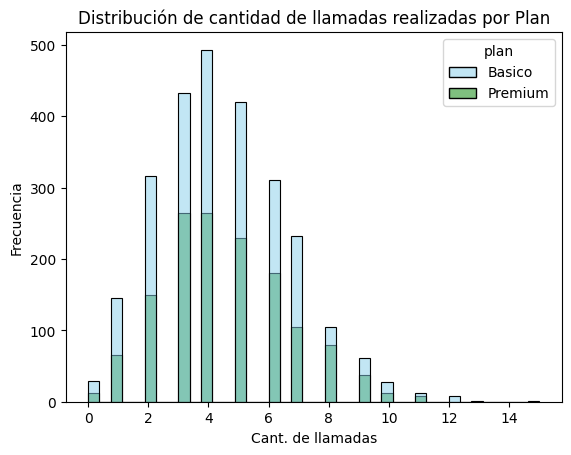

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de cantidad de llamadas realizadas por Plan')
plt.xlabel('Cant. de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución. Mismo caso o al menos muy parecido con la distribución de mensajes. Podemos ver que el comportamiento de los usuarios con plan básico como premium y similar, habiendo un pico entre 3 y 5 llamadas que son las que la mayoría de los usuarios realiza, y un sesgo a la derecha con muy pocos usuarios que hacen 9-10 llamadas o más. Volvemos a notar que el comportamiento de los usuarios es muy similar sin importar el tipo de plan.

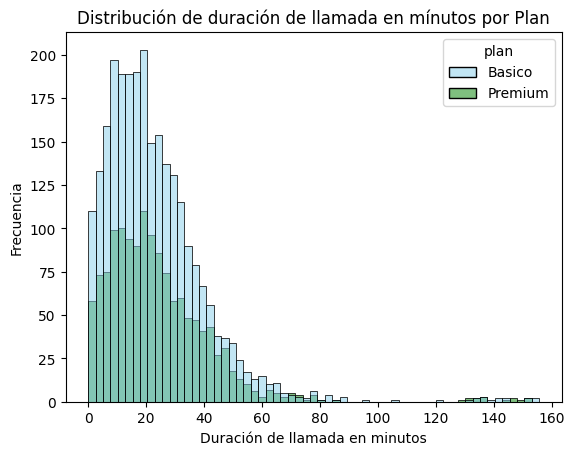

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de duración de llamada en mínutos por Plan')
plt.xlabel('Duración de llamada en minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Aquí si hay un sesgo muy claro a la derecha, pero era casi obvio que se iba a ver así, ya que cuando abalizamos los datos estadísticos, nos indicó que el máximo estaba muy por fuera del promedio, y que incluso el 75% estaban dentro de una duración de 31 minutos. Aún y cuando el valor máximo es muy extremo (151 min. aprox.), es un valor que puede ser real, ya que es una llamada de un poco menos de dos horas y media. Pero la gráifca nos deja claro que en promedio la gente habla de 10 a 20 minutos. Y con respecto al comportamiento de los usuarios según el plan, es muy similar. sin importar si es básico o premium el sesgo a la derecha está muy marcado. Lo único que se pudiera notar un poco diferente, es que parece indicar la gráfica que los valores extremos vienen principalmente de los usuarios con plan premium. Sin dejar de lado que también hay algunos usuarios con plan básico dentro de estos valores extremos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

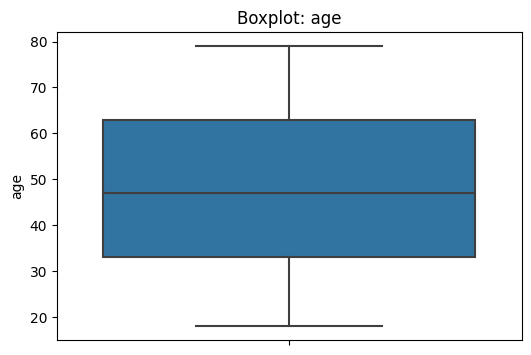

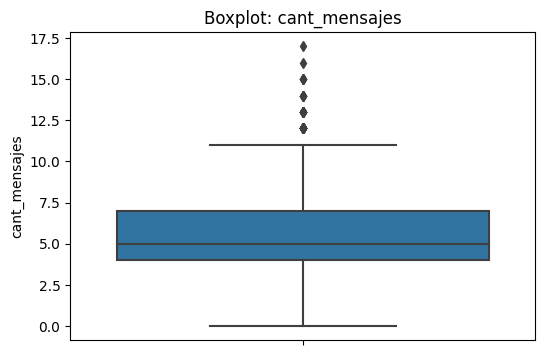

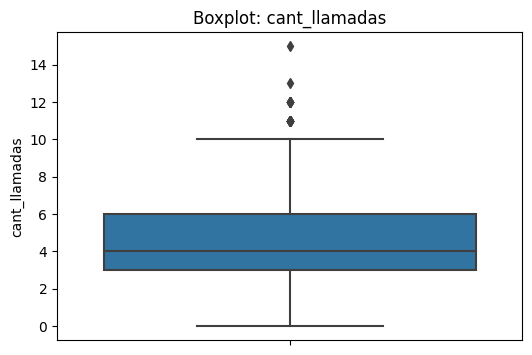

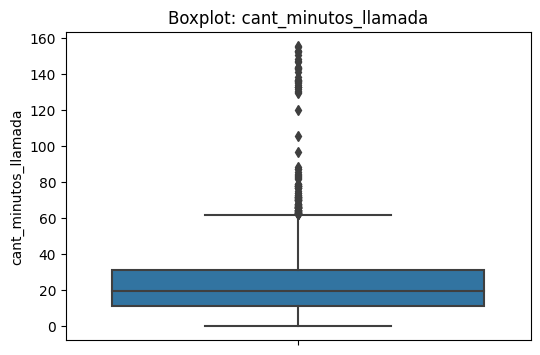

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, y=columna)
    plt.title(f'Boxplot: {columna}')
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers) No presenta outliers
- cant_mensajes: Según el boxplot, si presenta outliers
- cant_llamadas: Según el boxplot, si presenta outliers
- cant_minutos_llamada: Según el boxplot, si presenta outliers

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in columnas_limites:
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    valor_maximo = user_profile[columna].max()
    
    print(f"{columna}:")
    print(f"  Q1: {Q1}")
    print(f"  Q3: {Q3}")
    print(f"  IQR: {IQR}")
    print(f"  Límite superior: {limite_superior}")
    print(f"  Valor máximo: {valor_maximo}")
    print(f"  ¿Hay outliers?: {'SÍ' if valor_maximo > limite_superior else 'NO'}")
    print()

cant_mensajes:
  Q1: 4.0
  Q3: 7.0
  IQR: 3.0
  Límite superior: 11.5
  Valor máximo: 17.0
  ¿Hay outliers?: SÍ

cant_llamadas:
  Q1: 3.0
  Q3: 6.0
  IQR: 3.0
  Límite superior: 10.5
  Valor máximo: 15.0
  ¿Hay outliers?: SÍ

cant_minutos_llamada:
  Q1: 11.12
  Q3: 31.415
  IQR: 20.295
  Límite superior: 61.8575
  Valor máximo: 155.69
  ¿Hay outliers?: SÍ



In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Si mantener, porque aunque son outliers, son escenarios posibles. ¿Aumentan mucho el promedio? Si, más sin embargo, no son outliers imposibles, son escenarios que si se pudieran llegar a presentar y eliminarlos podría afectar nuestroa análisis. Y es el mismo caso para estas 3 columnas de datos.
- cant_llamadas: mantener o no outliers, porqué? Si mantener, porque aunque son outliers, son escenarios posibles. ¿Aumentan mucho el promedio? Si, más sin embargo, no son outliers imposibles, son escenarios que si se pudieran llegar a presentar y eliminarlos podría afectar nuestroa análisis. Y es el mismo caso para estas 3 columnas de datos.
- cant_minutos_llamada: mantener o no outliers, porqué? Si mantener, porque aunque son outliers, son escenarios posibles. ¿Aumentan mucho el promedio? Si, más sin embargo, no son outliers imposibles, son escenarios que si se pudieran llegar a presentar y eliminarlos podría afectar nuestroa análisis. Y es el mismo caso para estas 3 columnas de datos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:

# Crear columna grupo_uso

user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 
                          'Bajo uso', 
                            np.where(
                                (user_profile['cant_llamadas'] >= 5) & (user_profile['cant_llamadas'] < 10) & 
                                (user_profile['cant_mensajes'] >= 5) & (user_profile['cant_mensajes'] < 10),
                                'Uso medio', 
                                'Alto uso'
                            )
)



In [41]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Alto uso
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Alto uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [43]:
# Crear columna grupo_uso, cuando se cumple solo una condición (EXTRA)

user_profile['grupo_uso2'] = np.where(
    (user_profile['cant_llamadas'] < 5) | (user_profile['cant_mensajes'] < 5), 
                          'Bajo uso', 
                            np.where(
                                (user_profile['cant_llamadas'] >= 5) & (user_profile['cant_llamadas'] < 10) | 
                                (user_profile['cant_mensajes'] >= 5) & (user_profile['cant_mensajes'] < 10),
                                'Uso medio', 
                                'Alto uso'
                            )
)


In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_uso2
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Alto uso,Bajo uso
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Uso medio
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Alto uso,Bajo uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Bajo uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [130]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(
         user_profile['age'] < 60, 'Adulto', 'Adulto Mayor'
    )
)

In [131]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Alto uso,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Alto uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [46]:
user_profile['grupo_uso2'].value_counts()

Bajo uso     2819
Uso medio    1176
Alto uso        5
Name: grupo_uso2, dtype: int64

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

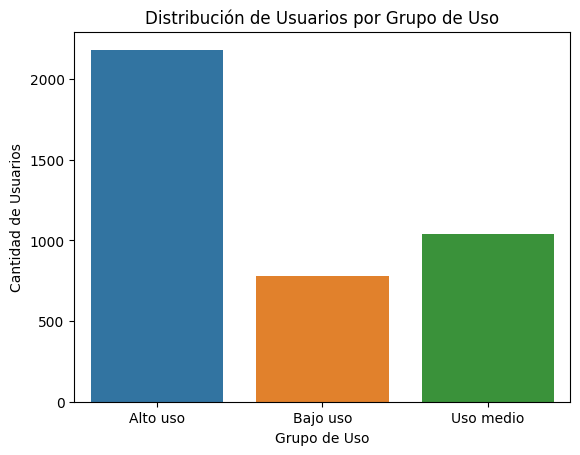

In [133]:

# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()



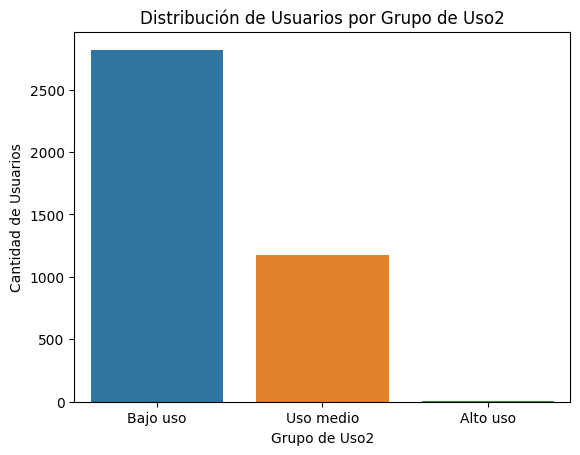

In [45]:
# Visualización de los segmentos por uso 2 cuando se cumple una u otra condición

sns.countplot(data=user_profile, x='grupo_uso2')
plt.title('Distribución de Usuarios por Grupo de Uso2')
plt.xlabel('Grupo de Uso2')
plt.ylabel('Cantidad de Usuarios')
plt.show()


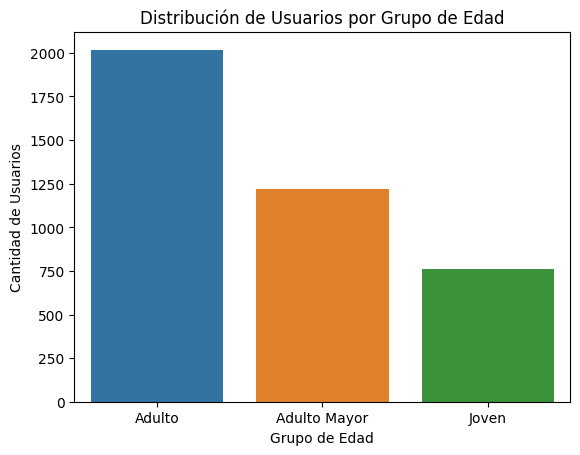

In [134]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? 

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Dfinitivamente el sector más valioso para ConnectaTel actualmente es el de los Adultos con plan básico, por la cantidad de usuarios que tienen y además que un buen porcentage cuenta con el plan Premium. Por otra parte, en el segmento de los Adulto Mayores, hay un secotr (de 72 a 79 años aprox.) que casi iguala la cantidad de usuarios Premium con Básico, lo cuál hace que sea un segmento valioso también.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Se detectaron muy pocos Outliers en la cantidad de llamadas y de mensajes, nomás en donde si hubo más Outliers fue en la cantidad de minutos por llamada. Las implicaciones es que nos deja ver que prácticamente el plan Básico cubre la nececidad promedio de casi todos los clientes. Con sus 100 mensajes y 100 minutos incluidos, son muy pocos los usuarios que requieren más minutos. 

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Realmente los datos estaban muy limpios, no era mucho lo que había que limpiar. Nomás la columna de fecha si hubo que cambiarla a tipo de dato fecha y hubo que eliminar algunas filas en donde se desconocía la ciudad. Pero realmente el procentage de datos eliminados o imputados fue muy bajo.


🔍📊 **Segmentos por Edad & Segmentos por Nivel de Uso**
Se solicitó dividir en 3 grupos diferentes de edad y 3 grupos diferentes de uso. Básicamente los el sector que tiene mayor cantidad de usuarios es el de adultos de 30 a 59 años y el que menos usuarios tiene es el de jovenes, menores a 30 años. Por otra parte parece que la mayoría de los usuarios están en el segmento de alto uso, sin embargo, creo que las instrucciones están mal, ya que nos pide identificar como bajo uso todo lo que sea menor de 5 llamadas y 5 mensajes, medio uso lo que esté entre 5-9 llamadas y 5-9 mensajes y todo lo demás alto uso. Sin embargo, hay un error ya que el sistema en caso de que por ejemplo un usuario tenga 3 mensajes y 7 llamadas, lo considera como alto uso porque no está dentro de los rangos de bajo y medio uso ya que no cumple las dos condiciones solicitadas. Pero ahí dice muy claro que tienen que ser ambas y que todo lo demás se considere Alto Uso.  

➡️ Esto sugiere que hay que aclarar la instrucción para que no se vea afectado el segmento por nivel de uso y poner gran enfoque en como atrapar más al segmento de jovenes.


💡 **Recomendaciones**
Me tomé la libertad de hace otra columna con grupo_uso2, en donde para estár en Alto uso tenía que cumplir las dos condiciones es decir enviar mínimo 10 mensajes y realizar mínimo 10 llamadas. Para Uso Medio, que estuviera cumpliera mínimo con una de las dos ya sea entre 5 y 9 llamadas o 5 y 9 mensajes y bajo uso cuando se cumple una u otra. Por qué, porque el Alto Uso se estaba viendo afectado. Si le interesa a la empresa pudieramos hacer dos tablas separadas una por mensajes y otra por llamadas para ser más acertivos y que no afecte una u otra por la condición de cualquier de las dos.
Mi recomendación primero que nada sería hacer una análisis del uso de GB, ya que hoy en día con los jovenes (sector de edad menos importante para la compañia), es muy importante por todas las redes sociales, por lo que quizás, si hubiera algún incentivo como IG incluido o What's App o TikTok o una de las redes sociales del momento, quizás con este tipo de promociones pudieramos atraer más la atención de jovenes e incrementar la presencia de ese sector en la compañia. 
Por otro lado, lo que yo haría es reducir un poco el costo del plan Premium o por tiempo limitado poner una promoción para ver si la gente quiere subir de nivel su plan, sin embargo, como comento hay que hacer un análisis de los GB en uso, porque creo que hoy en día es un factor importante y las llamadas y mensajes cada vez pasan más a segundo plano. 
En resumidas cuentas, recomendaría seguir con esos dos planes, ya que crear un plan superior a premium creo que no es necesario ya que justo la demanda de los usuario dicta que incluso casi con el Básico es suficiente. Y agregar uno antes del Básico, sería como darnos un balazo en el pie porque quizás estaríamos migrando algunos Básicos a un plan con menor costo. Lo único que recomiendo es hacer alguna promoción en el Premium esperando algunos usuarios nuevos o actuales realicen el cambio y hacer un análisis sobre el uso de datos ya que quizás esa información si nos da más para poder crear alguna otra estratégia. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`